> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API
%pip install -q coptpy


In [ ]:
# This case needs data files. Colab opens the notebook alone, so fetch them here.
import os, urllib.parse, urllib.request
BASE = 'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/Powering_a_Zero_Carbon_Island_Co_optimizing_Wind_Solar_and_Hydrogen_Storage/'
FILES = [
    'costs_2030.csv',
    'time-series.csv',
]
for f in FILES:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
        urllib.request.urlretrieve(BASE + urllib.parse.quote(f), f)
print(len(FILES), 'data file(s) ready')


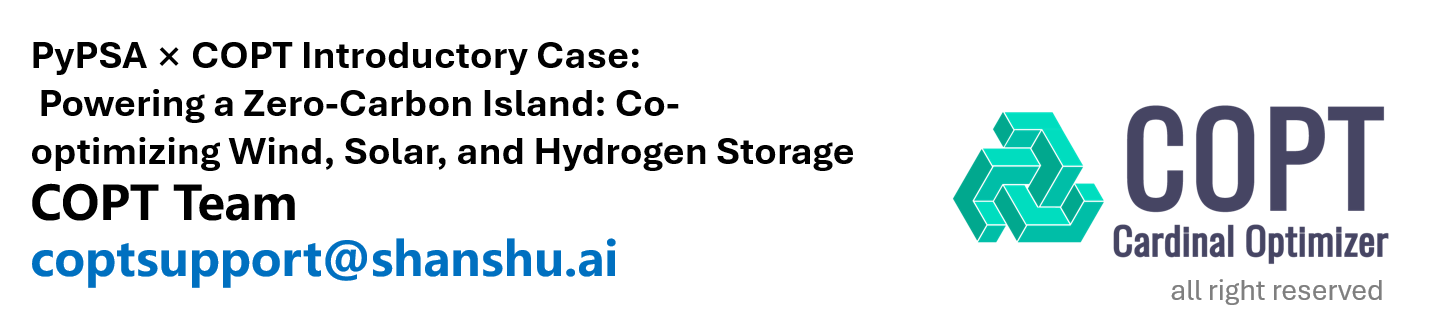

# PyPSA × COPT Introductory Case: Collaborative Optimization of Wind, Solar, Storage, and Hydrogen in a Zero-Carbon Island
> This case is adapted from the [PyPSA Official Example: 1-Node Capacity Expansion](https://docs.pypsa.org/latest/examples/capacity-expansion-planning-single-node/#wind-solar-and-load-time-series), and is built upon the original version by using the COPT solver as the underlying optimization computation engine.


## Import COPT-Python API
Import PyPSA, coptpy, and related dependency libraries.

In [1]:
import pypsa
from pypsa.costs import annuity

import pandas as pd
import coptpy

Cardinal Optimizer v8.0.3. Build date Jan 13 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Adding Model Data
The data in this case comes from two sources: the cost data for power generation units is from the [technology-data repository](https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{YEAR}.csv) maintained by PyPSA, while the solar irradiance and wind intensity data are from the database [tubcloud](https://tubcloud.tu-berlin.de/s/9toBssWEdaLgHzq/download/time-series.csv) maintained by Berlin University of Technology. Specifically:

- costs_2030.csv: Contains estimated costs (investment cost, O&M cost, lifetime, etc.) for various power generation and energy storage equipment in 2030.
- time-series.csv: Contains annual time-series data for wind power generation efficiency, photovoltaic (PV) generation efficiency, and electricity demand.

### Estimated Cost Data
We calculate two types of costs: marginal cost (the variable cost per unit of electricity generated, in €/MWh) and annualized capital cost (amortizing the one-time investment into an annual cost based on the discount rate and equipment lifetime, in €/MW/year).

A small utility function annuity is used here. It calculates the annuity factor based on the discount rate and equipment lifetime, thereby converting the one-time investment into an annual cost.

In [2]:
# Obtain Cost Data
YEAR = 2030
costs = pd.read_csv(f"costs_{YEAR}.csv", index_col=[0, 1])
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs = costs.value.unstack().fillna({"discount rate": 0.07, "lifetime": 20, "FOM": 0})

# Calculate Marginal Cost
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

# Calculate Annualized Cost
a = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (a + costs["FOM"] / 100) * costs["investment"]

### Wind, Solar, and Load Time Series Data
Here, the annual time-series data for wind power generation efficiency, photovoltaic (PV) generation efficiency, and electricity demand are read. In this case, we set the temporal resolution (RESOLUTION) to 3 hours. This data is fundamental for modeling and optimizing the scheduling and operation of the power system

In [3]:
# Wind, Solar, and Load Time Series
RESOLUTION = 3  # hours
ts = pd.read_csv("time-series.csv", index_col=0, parse_dates=True)[::RESOLUTION]
display(ts.head(3))

,load_mw,pv_pu,wind_pu
timestamp,,,
2019-01-01 00:00:00,5719.26,0.0,0.1846
2019-01-01 03:00:00,5474.74,0.0,0.3146
2019-01-01 06:00:00,5413.39,0.0,0.4957


## Initialize Model Network
Initialize an empty PyPSA network, add an electrical bus (Bus), and set time series snapshots.

Since we have downsampled the time series (one data point every 3 hours), we must set the snapshot weightings in n.snapshot_weightings (i.e., how many hours each snapshot represents); otherwise, the model will have errors when calculating the total annual cost and total power generation.

In [4]:
n = pypsa.Network()
n.add("Bus", "electricity", carrier="electricity")
n.set_snapshots(ts.index)
# Each time step represents 3 hours, and it is necessary to inform the model  of the time weight for each snapshot.
n.snapshot_weightings.loc[:, :] = RESOLUTION

### Adding Energy Carrier Classification
This step is only used for distinguishing colors during subsequent plotting and does not affect the optimization calculation ; it is not a mandatory requirement.

In [5]:
# Set energy carriers
carriers = [
    "wind",
    "solar",
    "hydrogen storage",
    "battery storage",
    "load shedding",
    "electrolysis",
    "turbine",
    "electricity",
    "hydrogen",
]

# Set colors for each carrier carrier
colors = [
    "dodgerblue",
    "gold",
    "black",
    "yellowgreen",
    "darkorange",
    "magenta",
    "red",
    "grey",
    "pink",
]
n.add("Carrier", carriers, color=colors)

### Adding Electricity Load
The p_set parameter  passes in the hourly actual electricity demand  time series for the whole year (unit: MW).

In [6]:
n.add(
    "Load",
    "demand",
    bus="electricity",
    p_set=ts.load_mw,
)

### Adding Generators
Add wind and solar power generators. Unlike conventional generators, renewable energy generators require passing a capacity factor time series via the p_max_pu parameter, which represents the upper limit of the maximum output of the generator at each time step (as a ratio relative to the installed capacity). p_nom_extendable=True indicates that the installed capacity is determined freely by the optimization model .

Additionally, a virtual load generator is added, with its marginal cost set to 2000 €/MWh, used to simulate the cost of "load shedding" during extreme power shortages .

In [7]:
# Wind
n.add(
    "Generator",
    "wind",
    bus="electricity",
    carrier="wind",
    p_max_pu=ts.wind_pu,
    capital_cost=costs.at["onwind", "capital_cost"],
    marginal_cost=costs.at["onwind", "marginal_cost"],
    p_nom_extendable=True,
)

# Solar
n.add(
    "Generator",
    "solar",
    bus="electricity",
    carrier="solar",
    p_max_pu=ts.pv_pu,
    capital_cost=costs.at["solar", "capital_cost"],
    marginal_cost=costs.at["solar", "marginal_cost"],
    p_nom_extendable=True,
)

# Add load generator to imitate the high cost of strike
n.add(
    "Generator",
    "load shedding",
    bus="electricity",
    carrier="load shedding",
    marginal_cost=2000,
    p_nom=ts.load_mw.max(),
)

### Adding Battery Storage Components
The investment cost of the battery consists of two parts: the inverter (power cost) and the battery unit (capacity cost). Here, it is assumed that the maximum continuous discharge time of the battery is 3 hours (max_hours=3).

In [8]:
# Battery
n.add(
    "StorageUnit",
    "battery storage",
    bus="electricity",
    carrier="battery storage",
    max_hours=3,
    capital_cost=costs.at["battery inverter", "capital_cost"]
    + 3 * costs.at["battery storage", "capital_cost"],
    efficiency_store=costs.at["battery inverter", "efficiency"],
    efficiency_dispatch=costs.at["battery inverter", "efficiency"],
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

### Adding a Hydrogen Storage System
Add a hydrogen energy storage system. This system is composed of three coordinated components: an electrolyzer (converting excess electricity into hydrogen), a hydrogen turbine (converting hydrogen back into electricity), and an underground hydrogen storage tank. The capacities of these three components can be flexibly optimized by the model .

#### Adding Link Components (Electrolyzer and Hydrogen Turbine) to Achieve Mutual Conversion Between Hydrogen and Electricity

In [9]:
n.add("Bus", "hydrogen", carrier="hydrogen")

n.add(
    "Link",
    "electrolysis",
    bus0="electricity",
    bus1="hydrogen",
    carrier="electrolysis",
    p_nom_extendable=True,
    efficiency=costs.at["electrolysis", "efficiency"],
    capital_cost=costs.at["electrolysis", "capital_cost"],
)

n.add(
    "Link",
    "turbine",
    bus0="hydrogen",
    bus1="electricity",
    carrier="turbine",
    p_nom_extendable=True,
    efficiency=costs.at["OCGT", "efficiency"],
    capital_cost=costs.at["OCGT", "capital_cost"] / costs.at["OCGT", "efficiency"],
)

#### Adding Hydrogen Storage Components (Underground Hydrogen Storage Tanks)

In [10]:
n.add(
    "Store",
    "hydrogen storage",
    bus="hydrogen",
    carrier="hydrogen storage",
    capital_cost=costs.at["hydrogen storage underground", "capital_cost"],
    e_nom_extendable=True,
    e_cyclic=True,
)

## Solve
PyPSA supports multiple solvers, and by default, it uses the open-source HiGHS solver. Here, we set the ``solver_name`` parameter to ``"copt"``, and PyPSA will automatically call the COPT solver at the lower level to handle this complex linear programming problem. COPT has efficient solving capabilities when dealing with such large-scale energy optimization problems. Before running, make sure you have installed the Python interface of COPT and completed the License configuration of COPT. You can refer to: [COPT User Manual](https://guide.coap.online/copt/zh-doc/).

In [11]:
# Set COPT solver
pypsa.options.params.optimize.solver_name = "copt"
n.optimize()

C:\Users\chent\AppData\Local\Temp\ipykernel_19760\46121970.py:3: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize()
INFO:linopy.model: Solve problem using Copt solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 11/11 [00:00<00:00, 436.44it/s]
INFO:linopy.io: Writing time: 0.27s


Cardinal Optimizer v8.0.3. Build date Jan 13 2026
Copyright Cardinal Operations 2026. All Rights Reserved

Reading from 'C:\Users\chent\AppData\Local\Temp\linopy-problem-hwdphceb.lp'
Reading finished (0.06s)
Model fingerprint: 57eea178

Using Cardinal Optimizer v8.0.3 on Windows (25H2 Build 26200 - x86_64)
The CPU model is 13th Gen Intel(R) Core(TM) i5-13500H
Hardware has 12 physical cores and 16 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an LP problem

The original problem has:
    64246 rows, 29206 columns and 124144 non-zero elements
The presolved problem has:
    30698 rows, 24864 columns and 86254 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [1e-01,8e+00]
    Range of rhs coefficients:       [6e+03,4e+04]
    Range of bound coefficients:     [1e+04,4e+04]
    Range of cost coefficients:      [4e+02,5e+05]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual  

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 29206 primals, 64246 duals
Objective: 1.01e+10
Solver model: available
Solver message: 1

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

## Obtaining Results
### Obtaining the Costs of Each Power Generation Measure
The annualized total cost (sum of capital expenditure and operating expenditure) of each power generation measure, in units of ten billion euros (GEur).

In [12]:
tsc = (
    pd.concat([n.statistics.capex(), n.statistics.opex()], axis=1).sum(axis=1).div(1e9)
)

tsc

component    carrier         
Generator    solar               1.684343
             wind                4.180646
Link         electrolysis        0.739954
             turbine             1.424007
StorageUnit  battery storage     1.124633
Store        hydrogen storage    0.688179
Generator    load shedding       0.290825
dtype: float64

### Obtain the total cost of the entire power generation system

In [13]:
tsc.sum()

np.float64(10.13258693337858)

### Obtain the optimal input quantities for various power generation measures
Unit: GW (The unit for the `Store` component is GWh)

In [14]:
n.statistics.optimal_capacity().div(1e3)

component    carrier         
Generator    load shedding         10.901160
             solar                 26.089521
             wind                  32.583318
Link         electrolysis           3.118498
             turbine                9.692634
StorageUnit  battery storage       14.047947
Store        hydrogen storage    3672.190855
dtype: float64

### Obtain the cumulative power generation or electricity consumption for each power generation measure throughout the year
Annual energy balance on the power side, in units of TWh. Positive values represent power supply, while negative values represent power consumption or charging:

In [15]:
n.statistics.energy_balance(bus_carrier="electricity").sort_values().div(1e6)

component    carrier          bus_carrier
Load         -                electricity   -66.266089
Link         electrolysis     electricity   -15.656979
StorageUnit  battery storage  electricity    -0.732725
Generator    load shedding    electricity     0.145412
Link         turbine          electricity     3.990917
Generator    solar            electricity    26.667456
             wind             electricity    51.852008
dtype: float64

### Annual Power Balance Chart
The positive areas in the graph (blue and gold) represent the power generation from wind and solar energy; the negative areas represent the electricity consumption and energy storage charging. It can be observed that: the solar power output is significantly higher in summer than in winter; during periods with abundant wind and solar resources, the excess electricity is stored in batteries or converted into hydrogen; the appearance of the orange area (load shedding, power rationing) indicates that the system, under the current cost parameters, has chosen "power rationing" over "capacity expansion"

(<Figure size 758.25x300 with 1 Axes>,
 <Axes: xlabel='snapshot', ylabel='Energy Balance []'>,
 <seaborn.axisgrid.FacetGrid at 0x1cf25fe3bf0>)

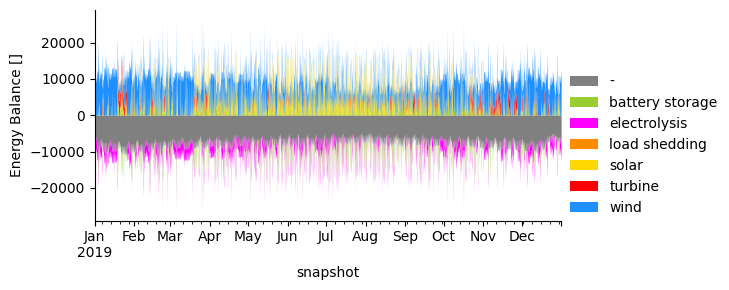

In [16]:
n.statistics.energy_balance.plot.area(linewidth=0, bus_carrier="electricity")

### Marginal Price Graph
The marginal price of electricity (blue line) is close to zero for the majority of the time, indicating abundant wind and solar power generation and almost no additional cost for the system to provide additional power. When there are price spikes (close to 2000 yuan/MWh), it indicates that the system is calling on virtual load generators (load shedding), and the high price at this time reflects the economic loss from power outages. The marginal price of hydrogen (orange line) is generally stable and low, reflecting the low cost of hydrogen as a long-term energy storage medium.

<Axes: xlabel='snapshot'>

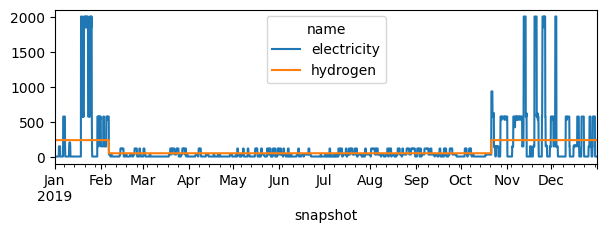

In [17]:
n.buses_t.marginal_price.plot(figsize=(7, 2))